### Random Forest — IEEE-CIS Fraud Detection

In [1]:
import sys
sys.path.append('.')

import os
import mlflow
import dagshub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from Models.preprocessing import load_data, FraudPreprocessor, ColumnSelector


from dotenv import load_dotenv; load_dotenv()
dagshub.init(repo_owner="lchit22", 
             repo_name="ml-assignment-fraud-detection", 
             mlflow=True)

EXPERIMENT_NAME = "RandomForest_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

Accessing as lchit22

Initialized MLflow to track repo "lchit22/ml-assignment-fraud-detection"

Repository lchit22/ml-assignment-fraud-detection initialized!

2026/05/05 00:11:39 INFO mlflow.tracking.fluent: Experiment with name 'RandomForest_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/5de56aa15fcb4493a1e3454d5b2fb4c4', creation_time=1777925500570, experiment_id='5', last_update_time=1777925500570, lifecycle_stage='active', name='RandomForest_Training', tags={}, trace_location=None, workspace='default'>

#### 1. Data Loading

Total transactions: 590,540
Fraud cases: 20,663 (3.50%)
Legitimate cases: 569,877
Total features: 432


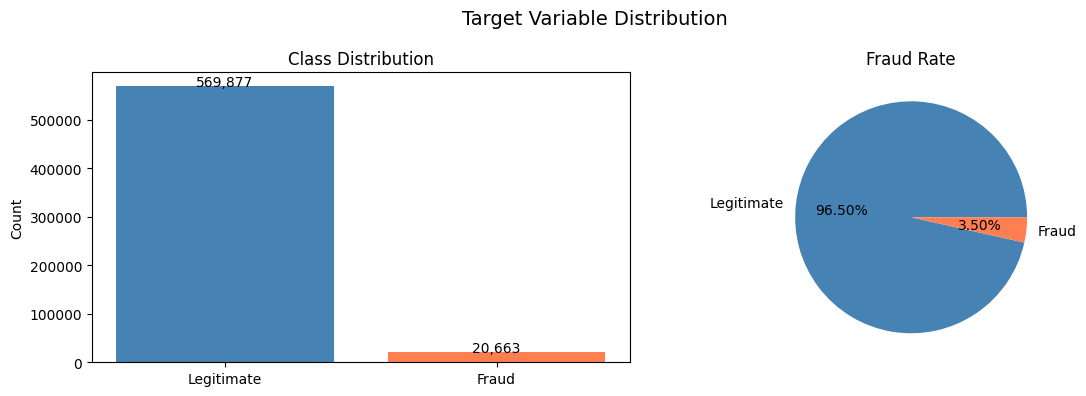


Train: (472432, 432), Val: (118108, 432)


In [2]:
mlflow.set_experiment(EXPERIMENT_NAME)

df = load_data()
X = df.drop(columns=['isFraud', 'TransactionID'])
y = df['isFraud']

print(f"Total transactions: {len(df):,}")
print(f"Fraud cases: {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"Legitimate cases: {(y==0).sum():,}")
print(f"Total features: {X.shape[1]}")

os.makedirs('Plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'],
            [y.value_counts()[0], y.value_counts()[1]],
            color=['steelblue', 'coral'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([y.value_counts()[0], y.value_counts()[1]]):
    axes[0].text(i, v + 100, f'{v:,}', ha='center')

axes[1].pie([y.value_counts()[0], y.value_counts()[1]],
            labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'coral'],
            autopct='%1.2f%%')
axes[1].set_title('Fraud Rate')

plt.suptitle('Target Variable Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('Plots/class_distribution.png')
plt.show()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}")

#### 2. Cleaning

2026/05/05 00:12:22 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



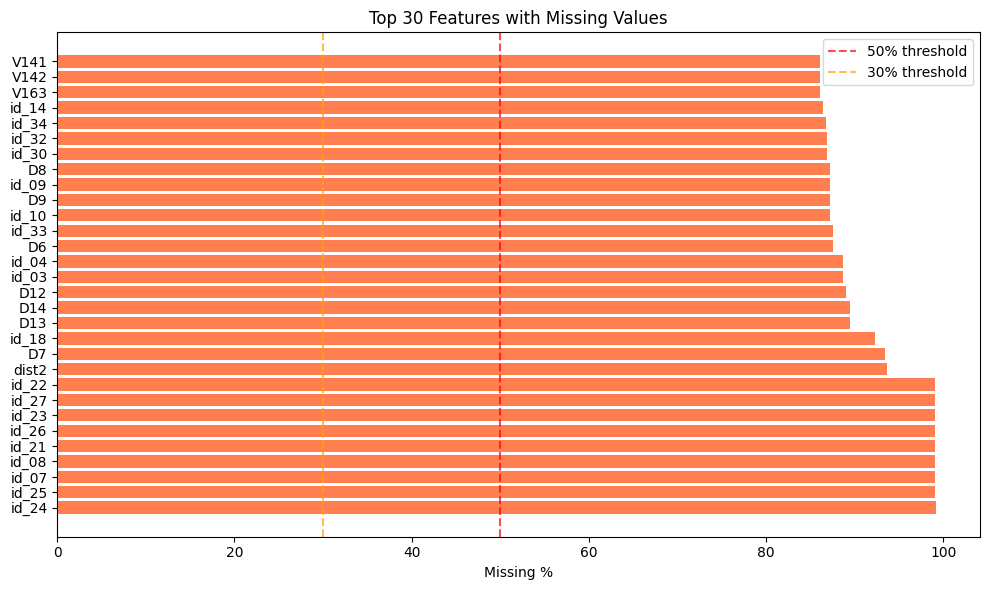

Total features: 432
Approach 1 (>50% missing): drop 214 columns
Approach 2 (>30% missing): drop 232 columns

Chosen: Approach 1 — drop extreme missing cases (>50%)
🏃 View run RandomForest_Cleaning at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5/runs/9ec644f4ac974fe4b93b78a703d6a707
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5


In [3]:
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="RandomForest_Cleaning"):

    missing_pct = X_train.isnull().mean().sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]

    fig, ax = plt.subplots(figsize=(10, 6))
    top_missing = missing_pct.head(30)
    colors = ['coral' if x > 0.5 else 'mediumpurple' if x > 0.3 else 'steelblue'
              for x in top_missing]
    ax.barh(top_missing.index, top_missing.values * 100, color=colors)
    ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
    ax.axvline(x=30, color='orange', linestyle='--', alpha=0.7, label='30% threshold')
    ax.set_xlabel('Missing %')
    ax.set_title('Top 30 Features with Missing Values')
    ax.legend()
    plt.tight_layout()
    plt.savefig('Plots/missing_values.png')
    plt.show()

    drop_50 = missing_pct[missing_pct > 0.5].index.tolist()
    drop_30 = missing_pct[missing_pct > 0.3].index.tolist()

    print(f"Total features: {X_train.shape[1]}")
    print(f"Approach 1 (>50% missing): drop {len(drop_50)} columns")
    print(f"Approach 2 (>30% missing): drop {len(drop_30)} columns")
    print(f"\nChosen: Approach 1 — drop extreme missing cases (>50%)")

    mlflow.log_param("chosen_threshold", 0.5)
    mlflow.log_param("approach1_threshold", 0.5)
    mlflow.log_param("approach2_threshold", 0.3)
    mlflow.log_metric("total_features", X_train.shape[1])
    mlflow.log_metric("approach1_dropped", len(drop_50))
    mlflow.log_metric("approach2_dropped", len(drop_30))
    mlflow.log_metric("missing_cols_total", len(missing_pct))
    mlflow.log_artifact('Plots/missing_values.png')

#### 3. Feature Engineering

C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['hour']                   = X['TransactionDT'] % 86400 // 3600
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['day_of_week']            = X['TransactionDT'] // 86400 % 7
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.p

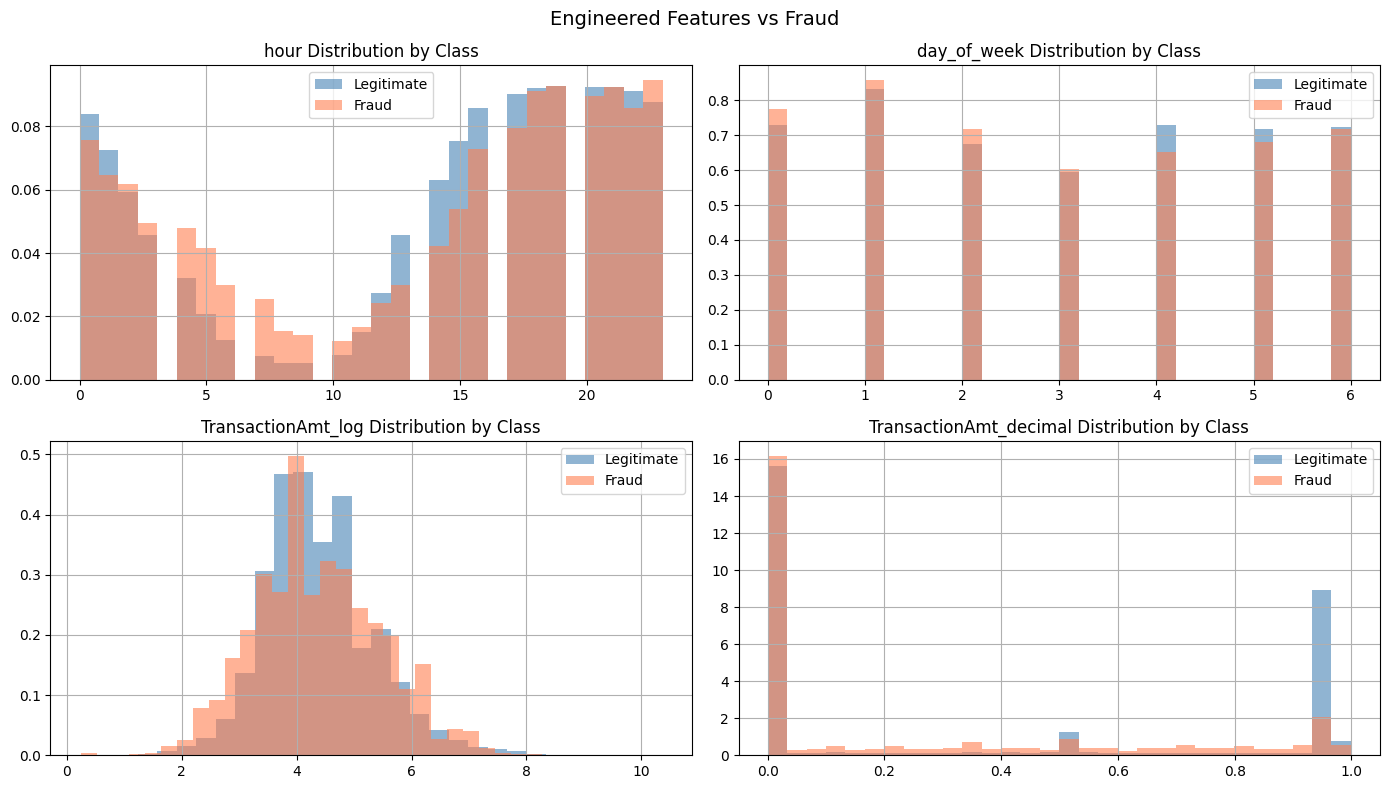

Features before:  432
Features after:   285

New features added: ['hour', 'day_of_week', 'TransactionAmt_log', 'TransactionAmt_decimal']
Raw TransactionDT and TransactionAmt dropped after engineering
🏃 View run RandomForest_FeatureEngineering at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5/runs/42f476fa1a0b4fa3bce764b98c0c3107
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5


In [4]:
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="RandomForest_FeatureEngineering"):

    prep = FraudPreprocessor()
    prep.fit(X_train)
    X_train_transformed = prep.transform(X_train)
    X_val_transformed   = prep.transform(X_val)

    new_features = ['hour', 'day_of_week',
                    'TransactionAmt_log', 'TransactionAmt_decimal']

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    for ax, feat in zip(axes.flatten(), new_features):
        df_plot = pd.DataFrame({
            feat: X_train_transformed[feat],
            'isFraud': y_train.values
        })
        df_plot[df_plot['isFraud'] == 0][feat].hist(
            ax=ax, bins=30, alpha=0.6, color='steelblue',
            label='Legitimate', density=True)
        df_plot[df_plot['isFraud'] == 1][feat].hist(
            ax=ax, bins=30, alpha=0.6, color='coral',
            label='Fraud', density=True)
        ax.set_title(f'{feat} Distribution by Class')
        ax.legend()

    plt.suptitle('Engineered Features vs Fraud', fontsize=14)
    plt.tight_layout()
    plt.savefig('Plots/feature_engineering.png')
    plt.show()

    mlflow.log_param("new_features", str(new_features))
    mlflow.log_param("drop_raw_TransactionDT", True)
    mlflow.log_param("drop_raw_TransactionAmt", True)
    mlflow.log_metric("features_before", X_train.shape[1])
    mlflow.log_metric("features_after_engineering", X_train_transformed.shape[1])
    mlflow.log_artifact('Plots/feature_engineering.png')

    print(f"Features before:  {X_train.shape[1]}")
    print(f"Features after:   {X_train_transformed.shape[1]}")
    print(f"\nNew features added: {new_features}")
    print(f"Raw TransactionDT and TransactionAmt dropped after engineering")

#### 4. Feature Selection

C:\Users\Likun\AppData\Local\Temp\ipykernel_22296\2913217172.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_iv.groupby('col')['target'].agg(['sum', 'count'])
C:\Users\Likun\AppData\Local\Temp\ipykernel_22296\2913217172.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_iv.groupby('col')['target'].agg(['sum', 'count'])
C:\Users\Likun\AppData\Local\Temp\ipykernel_22296\2913217172.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fu

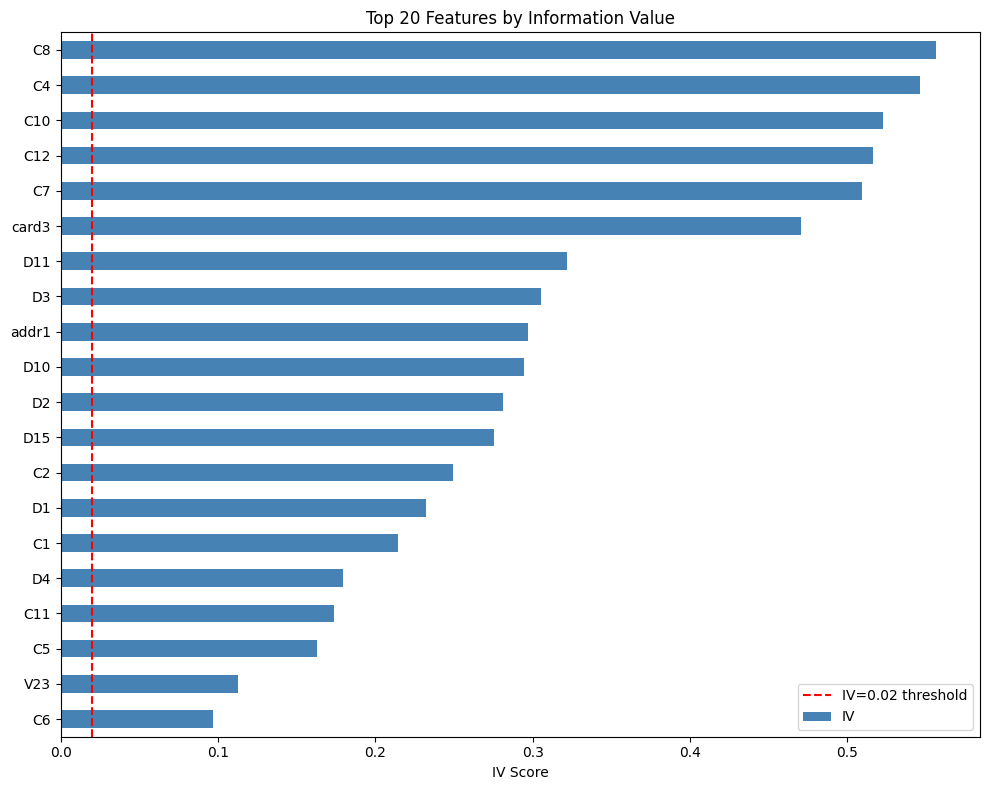

C:\Users\Likun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Likun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

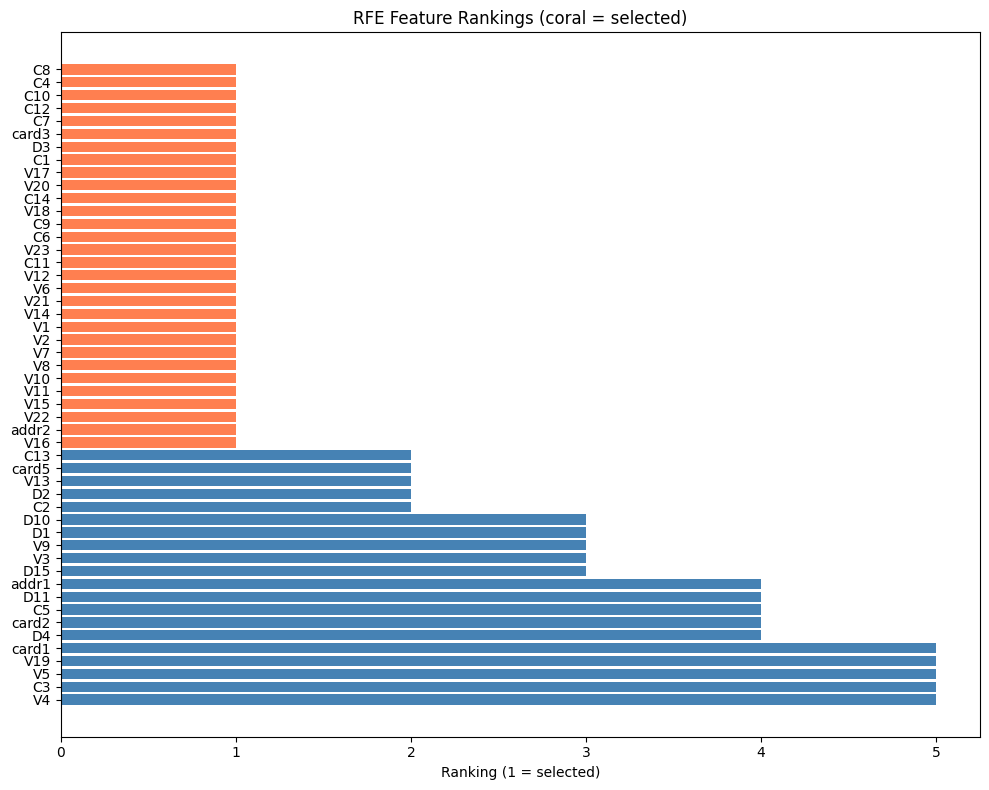

Approach 1 — IV (>0.02):              30 features
Approach 2 — RFE (LogisticRegression): 30 features

Chosen: IV selection (30 features)
🏃 View run RandomForest_FeatureSelection at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5/runs/66c61868f35542e899d2f0cb621aef04
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5


In [5]:
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="RandomForest_FeatureSelection"):

    def calculate_iv(X, y, col):
        df_iv = pd.DataFrame({'col': X[col], 'target': y.values})
        df_iv['col'] = pd.qcut(df_iv['col'], q=10, duplicates='drop')
        grouped = df_iv.groupby('col')['target'].agg(['sum', 'count'])
        grouped['non_event']      = grouped['count'] - grouped['sum']
        grouped['event_rate']     = grouped['sum'] / grouped['sum'].sum()
        grouped['non_event_rate'] = grouped['non_event'] / grouped['non_event'].sum()
        grouped['event_rate']     = grouped['event_rate'].replace(0, 0.0001)
        grouped['non_event_rate'] = grouped['non_event_rate'].replace(0, 0.0001)
        grouped['woe'] = np.log(grouped['event_rate'] / grouped['non_event_rate'])
        grouped['iv']  = (grouped['event_rate'] - grouped['non_event_rate']) * grouped['woe']
        return grouped['iv'].sum()

    num_cols = X_train_transformed.select_dtypes(include=np.number).columns.tolist()

    iv_scores = {}
    for col in num_cols[:50]:
        try:
            iv_scores[col] = calculate_iv(X_train_transformed, y_train, col)
        except:
            iv_scores[col] = 0

    iv_df = pd.DataFrame.from_dict(iv_scores, orient='index', columns=['IV'])
    iv_df = iv_df.sort_values('IV', ascending=False)
    iv_selected = iv_df[iv_df['IV'] > 0.02].index.tolist()

    fig, ax = plt.subplots(figsize=(10, 8))
    iv_df.head(20).plot(kind='barh', ax=ax, color='steelblue', legend=False)
    ax.axvline(x=0.02, color='red', linestyle='--', label='IV=0.02 threshold')
    ax.set_title('Top 20 Features by Information Value')
    ax.set_xlabel('IV Score')
    ax.invert_yaxis()
    ax.legend()
    plt.tight_layout()
    plt.savefig('Plots/rf_iv_scores.png')
    plt.show()

    top50_iv = iv_df.head(50).index.tolist()
    top50_iv = [c for c in top50_iv if c in X_train_transformed.columns]

    rfe = RFE(
        estimator=LogisticRegression(max_iter=100, random_state=42),
        n_features_to_select=30,
        step=5
    )
    rfe.fit(X_train_transformed[top50_iv], y_train)
    rfe_selected = [top50_iv[i] for i, s in enumerate(rfe.support_) if s]

    rfe_df = pd.DataFrame({
        'feature': top50_iv,
        'ranking': rfe.ranking_
    }).sort_values('ranking')

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['coral' if r == 1 else 'steelblue' for r in rfe_df['ranking']]
    ax.barh(rfe_df['feature'], rfe_df['ranking'], color=colors)
    ax.set_title('RFE Feature Rankings (coral = selected)')
    ax.set_xlabel('Ranking (1 = selected)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('Plots/rf_rfe_rankings.png')
    plt.show()

    selected_features = iv_selected if len(iv_selected) > 10 else top50_iv

    print(f"Approach 1 — IV (>0.02):              {len(iv_selected)} features")
    print(f"Approach 2 — RFE (LogisticRegression): {len(rfe_selected)} features")
    print(f"\nChosen: IV selection ({len(selected_features)} features)")

    mlflow.log_param("approach1", "Information Value > 0.02")
    mlflow.log_param("approach2", "RFE with LogisticRegression top 30")
    mlflow.log_param("chosen_approach", "IV" if len(iv_selected) > 10 else "top50_IV")
    mlflow.log_param("selected_features", str(selected_features))
    mlflow.log_metric("iv_selected_count", len(iv_selected))
    mlflow.log_metric("rfe_selected_count", len(rfe_selected))
    mlflow.log_metric("final_selected_count", len(selected_features))
    mlflow.log_artifact('Plots/rf_iv_scores.png')
    mlflow.log_artifact('Plots/rf_rfe_rankings.png')

#### 5. Training & Hyperparameter Tuning

C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['hour']                   = X['TransactionDT'] % 86400 // 3600
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['day_of_week']            = X['TransactionDT'] // 86400 % 7
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.p

underfit_1 | train=0.7814  val=0.7824  gap=-0.0010  [underfit]
🏃 View run RandomForest_underfit_1 at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5/runs/8f938f8e09cb4fd59d0daa77566a02de
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5


C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['hour']                   = X['TransactionDT'] % 86400 // 3600
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['day_of_week']            = X['TransactionDT'] // 86400 % 7
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.p

underfit_2 | train=0.7941  val=0.7933  gap=0.0008  [underfit]
🏃 View run RandomForest_underfit_2 at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5/runs/8a5b83a86005419989ee42015b319448
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5


C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['hour']                   = X['TransactionDT'] % 86400 // 3600
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['day_of_week']            = X['TransactionDT'] // 86400 % 7
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.p

...

overfit_10 | train=0.9975  val=0.9274  gap=0.0701  [overfit]
🏃 View run RandomForest_overfit_10 at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5/runs/c00a081562fd443eac54115931d96913
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5


C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['hour']                   = X['TransactionDT'] % 86400 // 3600
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['day_of_week']            = X['TransactionDT'] // 86400 % 7
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.p

overfit_11 | train=0.9936  val=0.9363  gap=0.0574  [overfit]
🏃 View run RandomForest_overfit_11 at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5/runs/db61945f831a4a50b46933ba86fd9fb7
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5


C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['hour']                   = X['TransactionDT'] % 86400 // 3600
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['day_of_week']            = X['TransactionDT'] // 86400 % 7
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.p

overfit_12 | train=0.9856  val=0.9336  gap=0.0520  [overfit]
🏃 View run RandomForest_overfit_12 at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5/runs/bf01d31a74ee45b2909f73cfdc6e64b2
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5
🏃 View run RandomForest_Training at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5/runs/2b245047b4ee4acea7140799ed4669ca
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/5

--- Results Summary ---
      label  n_estimators  max_depth  min_samples_split  min_samples_leaf  train_auc  val_auc     gap   status
 underfit_1             5        2.0                500               200     0.7814   0.7824 -0.0010 underfit
 underfit_2            10        2.0                500               200     0.7941   0.7933  0.0008 underfit
 underfit_3            10        3.0                200      

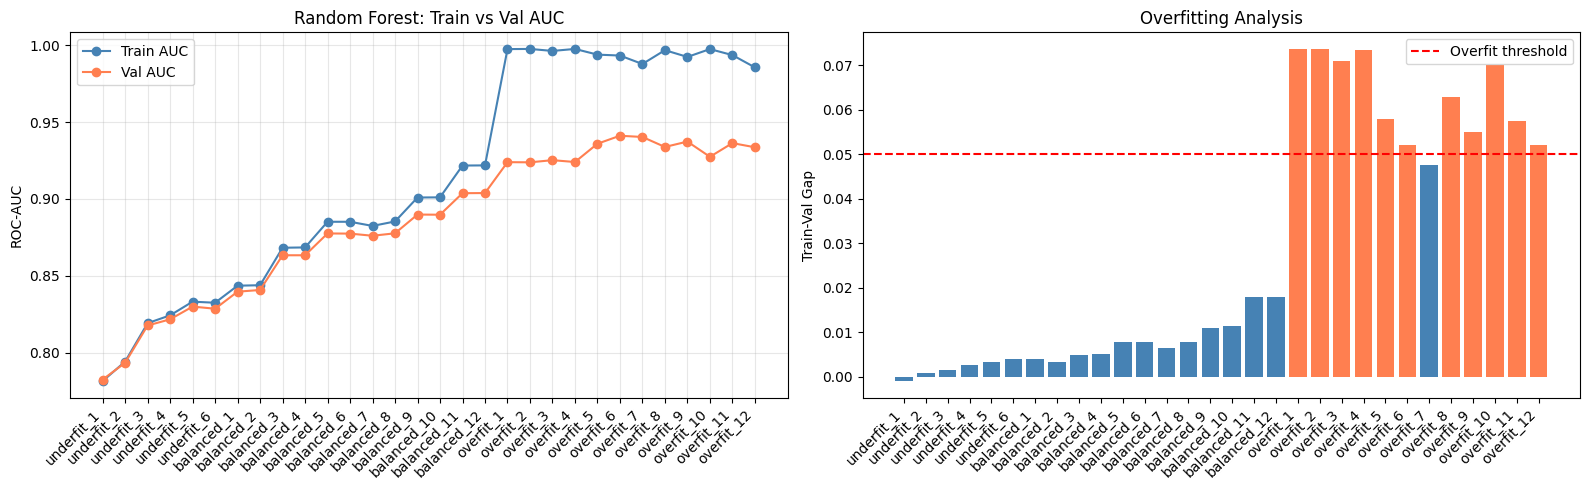

C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['hour']                   = X['TransactionDT'] % 86400 // 3600
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['day_of_week']            = X['TransactionDT'] // 86400 % 7
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.p

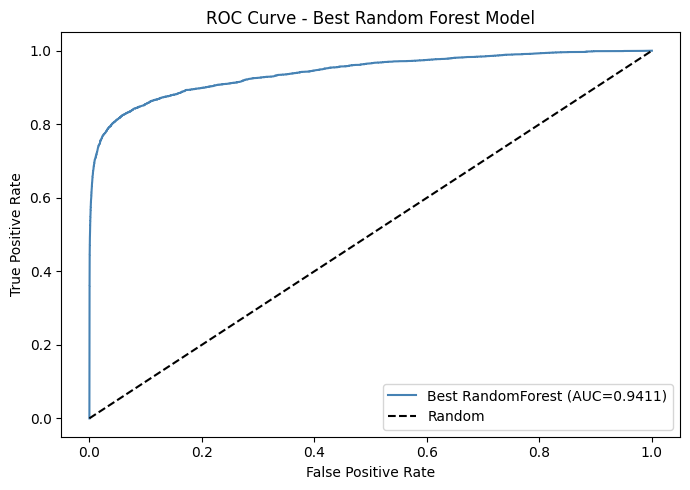


Best val_auc: 0.9411
Best run_id:  1b2cf27d88854fab98aa270ccd32dc53


In [6]:
mlflow.set_experiment(EXPERIMENT_NAME)

# Random Forest overfitting controlled by n_estimators, max_depth
# and min_samples — keep n_jobs=4 to avoid memory issues
param_grid = [
    # underfit — very few trees, shallow
    {'n_estimators':  5,  'max_depth':  2, 'min_samples_split': 500, 'min_samples_leaf': 200, 'label': 'underfit_1'},
    {'n_estimators': 10,  'max_depth':  2, 'min_samples_split': 500, 'min_samples_leaf': 200, 'label': 'underfit_2'},
    {'n_estimators': 10,  'max_depth':  3, 'min_samples_split': 200, 'min_samples_leaf': 100, 'label': 'underfit_3'},
    {'n_estimators': 20,  'max_depth':  3, 'min_samples_split': 200, 'min_samples_leaf': 100, 'label': 'underfit_4'},
    {'n_estimators': 20,  'max_depth':  4, 'min_samples_split': 200, 'min_samples_leaf': 100, 'label': 'underfit_5'},
    {'n_estimators': 30,  'max_depth':  4, 'min_samples_split': 200, 'min_samples_leaf': 100, 'label': 'underfit_6'},
    # balanced — moderate trees with constraints
    {'n_estimators':  50, 'max_depth':  5, 'min_samples_split':  50, 'min_samples_leaf':  20, 'label': 'balanced_1'},
    {'n_estimators': 100, 'max_depth':  5, 'min_samples_split':  50, 'min_samples_leaf':  20, 'label': 'balanced_2'},
    {'n_estimators': 100, 'max_depth':  8, 'min_samples_split':  50, 'min_samples_leaf':  20, 'label': 'balanced_3'},
    {'n_estimators': 150, 'max_depth':  8, 'min_samples_split':  50, 'min_samples_leaf':  20, 'label': 'balanced_4'},
    {'n_estimators': 150, 'max_depth': 10, 'min_samples_split':  50, 'min_samples_leaf':  20, 'label': 'balanced_5'},
    {'n_estimators': 200, 'max_depth': 10, 'min_samples_split':  50, 'min_samples_leaf':  20, 'label': 'balanced_6'},
    {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 100, 'min_samples_leaf':  50, 'label': 'balanced_7'},
    {'n_estimators': 250, 'max_depth': 10, 'min_samples_split':  50, 'min_samples_leaf':  20, 'label': 'balanced_8'},
    {'n_estimators': 250, 'max_depth': 12, 'min_samples_split':  50, 'min_samples_leaf':  20, 'label': 'balanced_9'},
    {'n_estimators': 300, 'max_depth': 12, 'min_samples_split':  50, 'min_samples_leaf':  20, 'label': 'balanced_10'},
    {'n_estimators': 300, 'max_depth': 15, 'min_samples_split':  50, 'min_samples_leaf':  20, 'label': 'balanced_11'},
    {'n_estimators': 350, 'max_depth': 15, 'min_samples_split':  50, 'min_samples_leaf':  20, 'label': 'balanced_12'},
    # overfit — many deep unconstrained trees
    {'n_estimators': 300, 'max_depth': None, 'min_samples_split':  2, 'min_samples_leaf':  1, 'label': 'overfit_1'},
    {'n_estimators': 350, 'max_depth': None, 'min_samples_split':  2, 'min_samples_leaf':  1, 'label': 'overfit_2'},
    {'n_estimators': 350, 'max_depth': None, 'min_samples_split':  5, 'min_samples_leaf':  1, 'label': 'overfit_3'},
    {'n_estimators': 400, 'max_depth': None, 'min_samples_split':  2, 'min_samples_leaf':  1, 'label': 'overfit_4'},
    {'n_estimators': 400, 'max_depth': None, 'min_samples_split':  5, 'min_samples_leaf':  2, 'label': 'overfit_5'},
    {'n_estimators': 400, 'max_depth': 30,   'min_samples_split':  2, 'min_samples_leaf':  1, 'label': 'overfit_6'},
    {'n_estimators': 400, 'max_depth': 30,   'min_samples_split':  5, 'min_samples_leaf':  2, 'label': 'overfit_7'},
    {'n_estimators': 400, 'max_depth': 40,   'min_samples_split':  2, 'min_samples_leaf':  1, 'label': 'overfit_8'},
    {'n_estimators': 400, 'max_depth': 40,   'min_samples_split':  5, 'min_samples_leaf':  2, 'label': 'overfit_9'},
    {'n_estimators': 400, 'max_depth': 50,   'min_samples_split':  2, 'min_samples_leaf':  1, 'label': 'overfit_10'},
    {'n_estimators': 400, 'max_depth': 50,   'min_samples_split':  5, 'min_samples_leaf':  2, 'label': 'overfit_11'},
    {'n_estimators': 400, 'max_depth': 50,   'min_samples_split': 10, 'min_samples_leaf':  5, 'label': 'overfit_12'},
]

results      = []
best_val_auc = 0
best_pipeline = None
best_run_id   = None

with mlflow.start_run(run_name="RandomForest_Training"):
    for params in param_grid:
        label = params.pop('label')

        with mlflow.start_run(run_name=f"RandomForest_{label}", nested=True):

            pipeline = Pipeline([
                ('preprocessor', FraudPreprocessor()),
                ('selector',     ColumnSelector(selected_features=selected_features)),
                ('model',        RandomForestClassifier(
                    **params,
                    random_state=42,
                    n_jobs=4
                ))
            ])

            pipeline.fit(X_train, y_train)

            train_auc = roc_auc_score(y_train, pipeline.predict_proba(X_train)[:, 1])
            val_auc   = roc_auc_score(y_val,   pipeline.predict_proba(X_val)[:, 1])
            gap       = train_auc - val_auc

            mlflow.log_params(params)
            mlflow.log_metric("train_auc",     train_auc)
            mlflow.log_metric("val_auc",       val_auc)
            mlflow.log_metric("train_val_gap", gap)
            mlflow.sklearn.log_model(pipeline, "model")

            status = ('overfit'  if gap > 0.05
                      else 'underfit' if val_auc < 0.85
                      else 'good')

            results.append({
                'label': label, **params,
                'train_auc': round(train_auc, 4),
                'val_auc':   round(val_auc,   4),
                'gap':       round(gap,        4),
                'status':    status
            })
            print(f"{label} | train={train_auc:.4f}  val={val_auc:.4f}  gap={gap:.4f}  [{status}]")

            if val_auc > best_val_auc:
                best_val_auc  = val_auc
                best_pipeline = pipeline
                best_run_id   = mlflow.active_run().info.run_id

        params['label'] = label

# results table
results_df = pd.DataFrame(results)
print("\n--- Results Summary ---")
print(results_df[['label', 'n_estimators', 'max_depth',
                   'min_samples_split', 'min_samples_leaf',
                   'train_auc', 'val_auc',
                   'gap', 'status']].to_string(index=False))

# charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = range(len(results_df))
axes[0].plot(x, results_df['train_auc'], 'o-', color='steelblue', label='Train AUC')
axes[0].plot(x, results_df['val_auc'],   'o-', color='coral',     label='Val AUC')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['label'], rotation=45, ha='right')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Random Forest: Train vs Val AUC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(results_df['label'], results_df['gap'], color=[
    'coral' if g > 0.05 else 'steelblue' for g in results_df['gap']
])
axes[1].axhline(y=0.05, color='red', linestyle='--', label='Overfit threshold')
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels(results_df['label'], rotation=45, ha='right')
axes[1].set_ylabel('Train-Val Gap')
axes[1].set_title('Overfitting Analysis')
axes[1].legend()

plt.tight_layout()
plt.savefig('Plots/rf_training.png')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_val, best_pipeline.predict_proba(X_val)[:, 1])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue',
         label=f'Best RandomForest (AUC={best_val_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Random Forest Model')
plt.legend()
plt.tight_layout()
plt.savefig('Plots/rf_roc.png')
plt.show()

mlflow.log_artifact('Plots/rf_training.png')
mlflow.log_artifact('Plots/rf_roc.png')

print(f"\nBest val_auc: {best_val_auc:.4f}")
print(f"Best run_id:  {best_run_id}")

#### 6. Model registration

In [7]:
from mlflow import MlflowClient
from mlflow.exceptions import MlflowException
from mlflow.store.artifact.runs_artifact_repo import RunsArtifactRepository

SOURCE_RUN_ID = "1b2cf27d88854fab98aa270ccd32dc53"
ARTIFACT_SUBPATH = "model"

run_id = SOURCE_RUN_ID
runs_uri = f"runs:/{run_id}/{ARTIFACT_SUBPATH}"
source = RunsArtifactRepository.get_underlying_uri(runs_uri)

client = MlflowClient()
try:
    client.create_registered_model("RandomForest_FraudDetection_Best")
except MlflowException as e:
    if e.error_code not in ("RESOURCE_ALREADY_EXISTS", "ALREADY_EXISTS"):
        raise

result = client.create_model_version(
    name="RandomForest_FraudDetection_Best",
    source=source,
    run_id=run_id,
)

print(f"Model registered: RandomForest_FraudDetection_Best")
print("Registered version:", result.version)
print(f"From run: {run_id}")

2026/05/05 10:07:41 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RandomForest_FraudDetection_Best, version 1


Model registered: RandomForest_FraudDetection_Best
Registered version: 1
From run: 1b2cf27d88854fab98aa270ccd32dc53
